# Traitement des Données - Prédiction de Churn

Ce notebook traite les problèmes de données dans le dataset Telco Customer Churn, notamment:
- Conversion des espaces vides en valeurs NaN
- Gestion des valeurs manquantes dans la colonne TotalCharges

In [16]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## 1. Chargement des Données

In [17]:
# Définition des chemins
DATA_PATH = Path(r"../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Chargement des données
df = pd.read_csv(DATA_PATH)

print(f"Dataset chargé: {df.shape[0]} lignes et {df.shape[1]} colonnes")
df.head()

Dataset chargé: 7043 lignes et 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Analyse Initiale des Données

In [18]:
# Informations sur le dataset
print("=" * 80)
print("INFORMATIONS GÉNÉRALES")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 80)
display(df.head(10))

INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 3. Analyse de la Colonne TotalCharges

La colonne `TotalCharges` contient des espaces vides pour les nouveaux clients (tenure = 0).

In [19]:
# Vérification du type de données actuel
print(f"Type de données de TotalCharges: {df['TotalCharges'].dtype}")
print(f"\nValeurs uniques (premières 20): {df['TotalCharges'].unique()[:20]}")

# Recherche des espaces vides
empty_charges = df[df['TotalCharges'] == ' ']
print(f"\n{'='*80}")
print(f"Nombre de lignes avec TotalCharges vide: {len(empty_charges)}")
print(f"Pourcentage: {len(empty_charges)/len(df)*100:.2f}%")
print(f"{'='*80}")

# Affichage des lignes avec valeurs vides
if len(empty_charges) > 0:
    print("\nExemples de lignes avec TotalCharges vide:")
    display(empty_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(10))

Type de données de TotalCharges: object

Valeurs uniques (premières 20): ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Nombre de lignes avec TotalCharges vide: 11
Pourcentage: 0.16%

Exemples de lignes avec TotalCharges vide:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Distribution de 'tenure' pour les lignes avec TotalCharges vide:
tenure
0    11
Name: count, dtype: int64


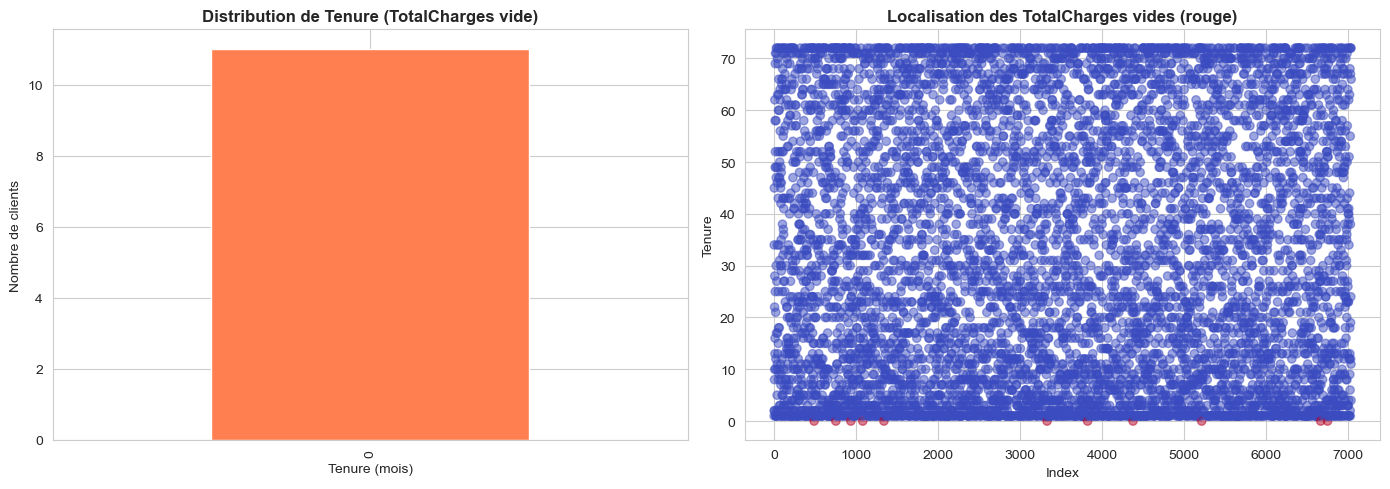

In [20]:
# Analyse de la relation entre tenure et TotalCharges vide
print("Distribution de 'tenure' pour les lignes avec TotalCharges vide:")
if len(empty_charges) > 0:
    print(empty_charges['tenure'].value_counts().sort_index())
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution de tenure pour les valeurs vides
    empty_charges['tenure'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Distribution de Tenure (TotalCharges vide)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Tenure (mois)')
    axes[0].set_ylabel('Nombre de clients')
    
    # Comparaison MonthlyCharges vs TotalCharges vide
    axes[1].scatter(df.index, df['tenure'], c=(df['TotalCharges'] == ' '), 
                   cmap='coolwarm', alpha=0.5)
    axes[1].set_title('Localisation des TotalCharges vides (rouge)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('Tenure')
    
    plt.tight_layout()
    plt.show()

## 4. Méthode Générique de Nettoyage des Données

In [21]:
def clean_numeric_column(df, column_name, verbose=True):
    """
    Nettoie une colonne numérique en convertissant les espaces vides en NaN.
    
    Paramètres:
    -----------
    df : pd.DataFrame
        Le DataFrame contenant les données
    column_name : str
        Nom de la colonne à nettoyer
    verbose : bool, default=True
        Afficher les informations de traitement
    
    Retour:
    -------
    pd.DataFrame
        DataFrame avec la colonne nettoyée
    """
    df_clean = df.copy()
    
    if verbose:
        print(f"Nettoyage de la colonne '{column_name}'...")
        print(f"Type de données avant: {df_clean[column_name].dtype}")
    
    # Remplacer les espaces vides par NaN
    df_clean[column_name] = df_clean[column_name].replace(' ', np.nan)
    
    # Convertir en numérique
    df_clean[column_name] = pd.to_numeric(df_clean[column_name], errors='coerce')
    
    if verbose:
        print(f"Type de données après: {df_clean[column_name].dtype}")
        print(f"Valeurs NaN créées: {df_clean[column_name].isna().sum()}")
        print(f"Pourcentage de NaN: {df_clean[column_name].isna().sum() / len(df_clean) * 100:.2f}%")
    
    return df_clean


def handle_missing_values(df, column_name, strategy='impute', impute_method='mean', verbose=True):
    """
    Gère les valeurs manquantes selon différentes stratégies.
    
    Paramètres:
    -----------
    df : pd.DataFrame
        Le DataFrame contenant les données
    column_name : str
        Nom de la colonne à traiter
    strategy : str, default='impute'
        Stratégie de gestion: 'impute' ou 'drop'
    impute_method : str, default='mean'
        Méthode d'imputation: 'mean', 'median', 'zero' ou 'monthly'
        'monthly' : utilise MonthlyCharges * tenure pour TotalCharges
    verbose : bool, default=True
        Afficher les informations de traitement
    
    Retour:
    -------
    pd.DataFrame
        DataFrame avec les valeurs manquantes traitées
    """
    df_processed = df.copy()
    missing_count_before = df_processed[column_name].isna().sum()
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"Gestion des valeurs manquantes pour '{column_name}'")
        print(f"Stratégie: {strategy}")
        if strategy == 'impute':
            print(f"Méthode d'imputation: {impute_method}")
        print(f"{'='*80}")
        print(f"Valeurs manquantes avant traitement: {missing_count_before}")
    
    if strategy == 'drop':
        # Supprimer les lignes avec valeurs manquantes
        df_processed = df_processed.dropna(subset=[column_name])
        if verbose:
            print(f"Lignes supprimées: {missing_count_before}")
            print(f"Nouvelles dimensions: {df_processed.shape}")
    
    elif strategy == 'impute':
        # Imputer les valeurs manquantes
        if impute_method == 'mean':
            impute_value = df_processed[column_name].mean()
            df_processed[column_name].fillna(impute_value, inplace=True)
            if verbose:
                print(f"Valeur d'imputation (moyenne): {impute_value:.2f}")
        
        elif impute_method == 'median':
            impute_value = df_processed[column_name].median()
            df_processed[column_name].fillna(impute_value, inplace=True)
            if verbose:
                print(f"Valeur d'imputation (médiane): {impute_value:.2f}")
        
        elif impute_method == 'zero':
            df_processed[column_name].fillna(0, inplace=True)
            if verbose:
                print("Valeur d'imputation: 0")
        
        elif impute_method == 'monthly' and column_name == 'TotalCharges':
            # Pour TotalCharges, utiliser MonthlyCharges * tenure
            mask = df_processed[column_name].isna()
            df_processed.loc[mask, column_name] = (
                df_processed.loc[mask, 'MonthlyCharges'] * df_processed.loc[mask, 'tenure']
            )
            if verbose:
                print("Imputation basée sur MonthlyCharges * tenure")
        
        missing_count_after = df_processed[column_name].isna().sum()
        if verbose:
            print(f"Valeurs manquantes après traitement: {missing_count_after}")
    
    if verbose:
        print(f"{'='*80}\n")
    
    return df_processed


print("Fonctions de nettoyage définies avec succès ✓")

Fonctions de nettoyage définies avec succès ✓


## 5. Application du Nettoyage

In [22]:
# Étape 1: Convertir les espaces vides en NaN
df_clean = clean_numeric_column(df, 'TotalCharges', verbose=True)

Nettoyage de la colonne 'TotalCharges'...
Type de données avant: object
Type de données après: float64
Valeurs NaN créées: 11
Pourcentage de NaN: 0.16%


In [23]:
# Visualisation des valeurs manquantes
print("\nAnalyse des lignes avec TotalCharges manquant:")
missing_totalcharges = df_clean[df_clean['TotalCharges'].isna()]
print(f"\nNombre de lignes: {len(missing_totalcharges)}")
print(f"\nCaractéristiques de ces clients:")
display(missing_totalcharges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(10))

# Statistiques
print("\nStatistiques de tenure pour les valeurs manquantes:")
print(missing_totalcharges['tenure'].describe())


Analyse des lignes avec TotalCharges manquant:

Nombre de lignes: 11

Caractéristiques de ces clients:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No



Statistiques de tenure pour les valeurs manquantes:
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


## 6. Comparaison des Stratégies de Gestion

Testons différentes approches pour gérer les valeurs manquantes:

In [24]:
# Stratégie 1: Suppression des lignes
print("\n" + "="*80)
print("STRATÉGIE 1: SUPPRESSION DES LIGNES")
print("="*80)
df_drop = handle_missing_values(df_clean, 'TotalCharges', strategy='drop', verbose=True)


STRATÉGIE 1: SUPPRESSION DES LIGNES

Gestion des valeurs manquantes pour 'TotalCharges'
Stratégie: drop
Valeurs manquantes avant traitement: 11
Lignes supprimées: 11
Nouvelles dimensions: (7032, 21)



In [25]:
# Stratégie 2: Imputation par la moyenne
print("\n" + "="*80)
print("STRATÉGIE 2: IMPUTATION PAR LA MOYENNE")
print("="*80)
df_mean = handle_missing_values(df_clean, 'TotalCharges', 
                                 strategy='impute', 
                                 impute_method='mean', 
                                 verbose=True)


STRATÉGIE 2: IMPUTATION PAR LA MOYENNE

Gestion des valeurs manquantes pour 'TotalCharges'
Stratégie: impute
Méthode d'imputation: mean
Valeurs manquantes avant traitement: 11
Valeur d'imputation (moyenne): 2283.30
Valeurs manquantes après traitement: 0



C:\Users\alexi\AppData\Local\Temp\ipykernel_32092\3255634206.py:85: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[column_name].fillna(impute_value, inplace=True)


In [26]:
# Stratégie 3: Imputation par zéro (logique pour tenure = 0)
print("\n" + "="*80)
print("STRATÉGIE 3: IMPUTATION PAR ZÉRO")
print("="*80)
df_zero = handle_missing_values(df_clean, 'TotalCharges', 
                                 strategy='impute', 
                                 impute_method='zero', 
                                 verbose=True)


STRATÉGIE 3: IMPUTATION PAR ZÉRO

Gestion des valeurs manquantes pour 'TotalCharges'
Stratégie: impute
Méthode d'imputation: zero
Valeurs manquantes avant traitement: 11
Valeur d'imputation: 0
Valeurs manquantes après traitement: 0



C:\Users\alexi\AppData\Local\Temp\ipykernel_32092\3255634206.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[column_name].fillna(0, inplace=True)


In [27]:
# Stratégie 4: Imputation basée sur MonthlyCharges * tenure (RECOMMANDÉ)
print("\n" + "="*80)
print("STRATÉGIE 4: IMPUTATION PAR MonthlyCharges × tenure (RECOMMANDÉ)")
print("="*80)
df_monthly = handle_missing_values(df_clean, 'TotalCharges', 
                                    strategy='impute', 
                                    impute_method='monthly', 
                                    verbose=True)


STRATÉGIE 4: IMPUTATION PAR MonthlyCharges × tenure (RECOMMANDÉ)

Gestion des valeurs manquantes pour 'TotalCharges'
Stratégie: impute
Méthode d'imputation: monthly
Valeurs manquantes avant traitement: 11
Imputation basée sur MonthlyCharges * tenure
Valeurs manquantes après traitement: 0



## 7. Visualisation Comparative

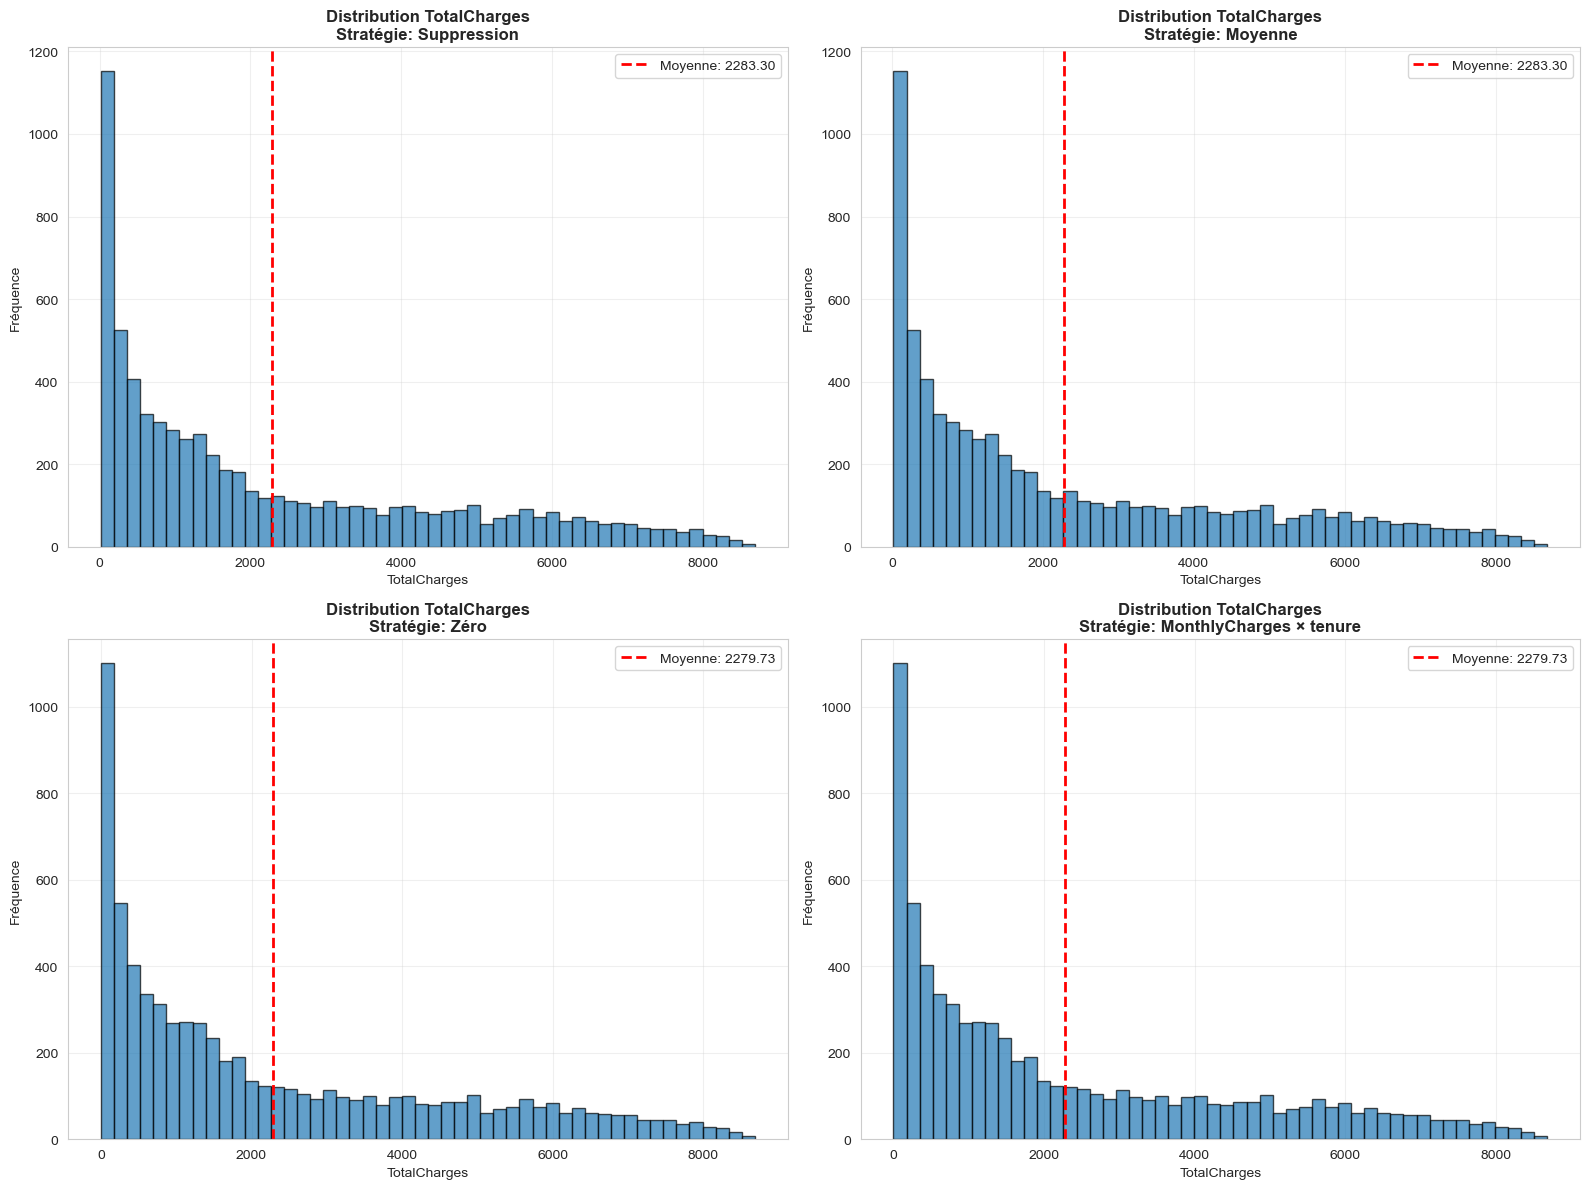


STATISTIQUES COMPARATIVES


,Stratégie,Nombre de lignes,Moyenne TotalCharges,Médiane TotalCharges,Écart-type
0,Suppression,7032,2283.300441,1397.475,2266.771362
1,Moyenne,7043,2283.300441,1400.550,2265.000258
2,Zéro,7043,2279.734304,1394.550,2266.794470
3,Monthly×Tenure,7043,2279.734304,1394.550,2266.794470


In [28]:
# Comparaison des distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies = [
    (df_drop, 'Suppression'),
    (df_mean, 'Moyenne'),
    (df_zero, 'Zéro'),
    (df_monthly, 'MonthlyCharges × tenure')
]

for idx, (data, label) in enumerate(strategies):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Histogramme
    ax.hist(data['TotalCharges'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution TotalCharges\nStratégie: {label}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('TotalCharges')
    ax.set_ylabel('Fréquence')
    ax.axvline(data['TotalCharges'].mean(), color='red', linestyle='--', 
              linewidth=2, label=f'Moyenne: {data["TotalCharges"].mean():.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques comparatives
print("\n" + "="*80)
print("STATISTIQUES COMPARATIVES")
print("="*80)

comparison_df = pd.DataFrame({
    'Stratégie': ['Suppression', 'Moyenne', 'Zéro', 'Monthly×Tenure'],
    'Nombre de lignes': [len(df_drop), len(df_mean), len(df_zero), len(df_monthly)],
    'Moyenne TotalCharges': [
        df_drop['TotalCharges'].mean(),
        df_mean['TotalCharges'].mean(),
        df_zero['TotalCharges'].mean(),
        df_monthly['TotalCharges'].mean()
    ],
    'Médiane TotalCharges': [
        df_drop['TotalCharges'].median(),
        df_mean['TotalCharges'].median(),
        df_zero['TotalCharges'].median(),
        df_monthly['TotalCharges'].median()
    ],
    'Écart-type': [
        df_drop['TotalCharges'].std(),
        df_mean['TotalCharges'].std(),
        df_zero['TotalCharges'].std(),
        df_monthly['TotalCharges'].std()
    ]
})

display(comparison_df)

## 8. Recommandation et Sauvegarde

**Recommandation**: La stratégie **MonthlyCharges × tenure** est la plus appropriée car:
- Elle préserve toutes les données
- Elle est logique: TotalCharges devrait être proche de MonthlyCharges × tenure
- Pour les nouveaux clients (tenure=0), TotalCharges devient 0, ce qui est cohérent

In [29]:
# Utiliser la stratégie recommandée
df_final = df_monthly.copy()

# Vérification finale
print("Vérification finale du dataset nettoyé:")
print(f"\nDimensions: {df_final.shape}")
print(f"Valeurs manquantes dans TotalCharges: {df_final['TotalCharges'].isna().sum()}")
print(f"Type de données TotalCharges: {df_final['TotalCharges'].dtype}")

# Statistiques descriptives
print("\nStatistiques de TotalCharges:")
print(df_final['TotalCharges'].describe())

Vérification finale du dataset nettoyé:

Dimensions: (7043, 21)
Valeurs manquantes dans TotalCharges: 0
Type de données TotalCharges: float64

Statistiques de TotalCharges:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [30]:
# Sauvegarde du dataset nettoyé
OUTPUT_PATH = Path(r"../data/processed/telco_customer_churn_clean.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_final.to_csv(OUTPUT_PATH, index=False)
print(f"✓ Dataset nettoyé sauvegardé: {OUTPUT_PATH}")
print(f"✓ {len(df_final)} lignes et {len(df_final.columns)} colonnes")

✓ Dataset nettoyé sauvegardé: ..\data\processed\telco_customer_churn_clean.csv
✓ 7043 lignes et 21 colonnes


## 9. Résumé

### Actions Effectuées:
1. ✓ Chargement du dataset original
2. ✓ Identification des espaces vides dans `TotalCharges`
3. ✓ Conversion des espaces vides en valeurs `NaN`
4. ✓ Comparaison de 4 stratégies de gestion des valeurs manquantes
5. ✓ Application de la stratégie recommandée (MonthlyCharges × tenure)
6. ✓ Sauvegarde du dataset nettoyé

### Résultat:
- **Dataset nettoyé**: `telco_customer_churn_clean.csv`
- **Toutes les données préservées**: Aucune ligne supprimée
- **Valeurs manquantes**: 0
- **Type de données correct**: float64 pour TotalCharges

# ===========================================================================
## 9 : ENCODAGE DES VARIABLES CATÉGORIELLES ET SCALING
# ===========================================================================

## 9. Encodage des Variables Catégorielles et Scaling

Pour préparer les données au machine learning, nous devons :
1. **Encoder les variables catégorielles** en numériques
2. **Normaliser les variables numériques** pour qu'elles aient la même échelle


### 9.1 Analyse des Types de Variables


Identifier les différents types de colonnes

In [31]:
print("=" * 80)
print("ANALYSE DES TYPES DE VARIABLES")
print("=" * 80)

# Colonnes numériques
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nColonnes numériques ({len(numeric_cols)}):")
print(numeric_cols)

# Colonnes catégorielles
categorical_cols = df_final.select_dtypes(include=['object']).columns.tolist()
print(f"\nColonnes catégorielles ({len(categorical_cols)}):")
print(categorical_cols)

# Analyser le nombre de valeurs uniques par colonne catégorielle
print("\n" + "=" * 80)
print("VALEURS UNIQUES PAR COLONNE CATÉGORIELLE")
print("=" * 80)
for col in categorical_cols:
    unique_vals = df_final[col].nunique()
    print(f"{col:20} -> {unique_vals} valeurs uniques: {df_final[col].unique()[:5]}")




ANALYSE DES TYPES DE VARIABLES

Colonnes numériques (4):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Colonnes catégorielles (17):
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

VALEURS UNIQUES PAR COLONNE CATÉGORIELLE
customerID           -> 7043 valeurs uniques: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
gender               -> 2 valeurs uniques: ['Female' 'Male']
Partner              -> 2 valeurs uniques: ['Yes' 'No']
Dependents           -> 2 valeurs uniques: ['No' 'Yes']
PhoneService         -> 2 valeurs uniques: ['No' 'Yes']
MultipleLines        -> 3 valeurs uniques: ['No phone service' 'No' 'Yes']
InternetService      -> 3 valeurs uniques: ['DSL' 'Fiber optic' 'No']
OnlineSecurity       -> 3 valeurs uniques: ['No' 'Yes' 'No 

## 9.2 Identification des Variables Binaires vs Multi-catégorielles

Séparer les colonnes binaires (2 valeurs) et multi-catégorielles (>2 valeurs)


In [32]:
binary_cols = []
multi_categorical_cols = []

# Exclure customerID et Churn (notre target)
categorical_features = [col for col in categorical_cols if col not in ['customerID', 'Churn']]

for col in categorical_features:
    unique_count = df_final[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    elif unique_count > 2:
        multi_categorical_cols.append(col)

print("=" * 80)
print("CLASSIFICATION DES VARIABLES CATÉGORIELLES")
print("=" * 80)
print(f"\n📊 Variables BINAIRES ({len(binary_cols)}) - LabelEncoder:")
for col in binary_cols:
    print(f"   - {col:20} : {df_final[col].unique()}")

print(f"\n📊 Variables MULTI-CATÉGORIELLES ({len(multi_categorical_cols)}) - OneHotEncoder:")
for col in multi_categorical_cols:
    print(f"   - {col:20} : {df_final[col].unique()}")

CLASSIFICATION DES VARIABLES CATÉGORIELLES

📊 Variables BINAIRES (5) - LabelEncoder:
   - gender               : ['Female' 'Male']
   - Partner              : ['Yes' 'No']
   - Dependents           : ['No' 'Yes']
   - PhoneService         : ['No' 'Yes']
   - PaperlessBilling     : ['Yes' 'No']

📊 Variables MULTI-CATÉGORIELLES (10) - OneHotEncoder:
   - MultipleLines        : ['No phone service' 'No' 'Yes']
   - InternetService      : ['DSL' 'Fiber optic' 'No']
   - OnlineSecurity       : ['No' 'Yes' 'No internet service']
   - OnlineBackup         : ['Yes' 'No' 'No internet service']
   - DeviceProtection     : ['No' 'Yes' 'No internet service']
   - TechSupport          : ['No' 'Yes' 'No internet service']
   - StreamingTV          : ['No' 'Yes' 'No internet service']
   - StreamingMovies      : ['No' 'Yes' 'No internet service']
   - Contract             : ['Month-to-month' 'One year' 'Two year']
   - PaymentMethod        : ['Electronic check' 'Mailed check' 'Bank transfer (automatic

 ### 9.3 Encodage avec LabelEncoder (Variables Binaires)

In [33]:
from sklearn.preprocessing import LabelEncoder

# Créer une copie du dataframe pour les transformations
df_encoded = df_final.copy()

# Dictionnaire pour stocker les encoders (utile pour l'inversion si nécessaire)
label_encoders = {}

print("=" * 80)
print("ENCODAGE DES VARIABLES BINAIRES (LabelEncoder)")
print("=" * 80)

for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_final[col])
    label_encoders[col] = le
    
    # Afficher le mapping
    print(f"✓ {col:20} : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encoder aussi la variable cible (Churn)
le_churn = LabelEncoder()
df_encoded['Churn'] = le_churn.fit_transform(df_final['Churn'])
label_encoders['Churn'] = le_churn
print(f"\n🎯 Churn (Target)       : {dict(zip(le_churn.classes_, le_churn.transform(le_churn.classes_)))}")


ENCODAGE DES VARIABLES BINAIRES (LabelEncoder)
✓ gender               : {'Female': 0, 'Male': 1}
✓ Partner              : {'No': 0, 'Yes': 1}
✓ Dependents           : {'No': 0, 'Yes': 1}
✓ PhoneService         : {'No': 0, 'Yes': 1}
✓ PaperlessBilling     : {'No': 0, 'Yes': 1}

🎯 Churn (Target)       : {'No': 0, 'Yes': 1}


### 9.4 Encodage avec OneHotEncoder (Variables Multi-catégorielles)

In [34]:
# One-Hot Encoding pour les variables multi-catégorielles
print("\n" + "=" * 80)
print("ENCODAGE DES VARIABLES MULTI-CATÉGORIELLES (OneHotEncoder)")
print("=" * 80)

# Utiliser pd.get_dummies avec drop_first=True pour éviter la multicolinéarité
df_encoded = pd.get_dummies(df_encoded, columns=multi_categorical_cols, drop_first=True, dtype=int)

print(f"✓ Variables créées par OneHotEncoding:")
new_cols = [col for col in df_encoded.columns if any(cat in col for cat in multi_categorical_cols)]
for col in sorted(new_cols):
    print(f"   - {col}")

print(f"\n📊 Nouvelles dimensions du dataset: {df_encoded.shape}")



ENCODAGE DES VARIABLES MULTI-CATÉGORIELLES (OneHotEncoder)
✓ Variables créées par OneHotEncoding:
   - Contract_One year
   - Contract_Two year
   - DeviceProtection_No internet service
   - DeviceProtection_Yes
   - InternetService_Fiber optic
   - InternetService_No
   - MultipleLines_No phone service
   - MultipleLines_Yes
   - OnlineBackup_No internet service
   - OnlineBackup_Yes
   - OnlineSecurity_No internet service
   - OnlineSecurity_Yes
   - PaymentMethod_Credit card (automatic)
   - PaymentMethod_Electronic check
   - PaymentMethod_Mailed check
   - StreamingMovies_No internet service
   - StreamingMovies_Yes
   - StreamingTV_No internet service
   - StreamingTV_Yes
   - TechSupport_No internet service
   - TechSupport_Yes

📊 Nouvelles dimensions du dataset: (7043, 32)


 ### 9.5 Scaling des Variables Numériques avec StandardScaler



In [35]:
from sklearn.preprocessing import StandardScaler

# Identifier les colonnes numériques à scaler (exclure customerID et la target)
# Les variables déjà binaires (0/1) n'ont pas besoin de scaling
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("=" * 80)
print("SCALING DES VARIABLES NUMÉRIQUES (StandardScaler)")
print("=" * 80)

# Afficher les statistiques AVANT scaling
print("\n📊 Statistiques AVANT scaling:")
print(df_encoded[cols_to_scale].describe().round(2))

# Appliquer le StandardScaler
scaler = StandardScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# Afficher les statistiques APRÈS scaling
print("\n📊 Statistiques APRÈS scaling:")
print(df_encoded[cols_to_scale].describe().round(2))

print("\n✓ Les variables scalées ont maintenant une moyenne ≈ 0 et un écart-type ≈ 1")


SCALING DES VARIABLES NUMÉRIQUES (StandardScaler)

📊 Statistiques AVANT scaling:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

📊 Statistiques APRÈS scaling:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.32           -1.55         -1.01
25%      -0.95           -0.97         -0.83
50%      -0.14            0.19         -0.39
75%       0.92            0.83          0.66
max       1.61            1.79          2.83

✓ Les variables scalées ont maintenant une moyenne ≈ 0 et un écart-type ≈ 1


### 9.6 Visualisation : Avant vs Après Scaling

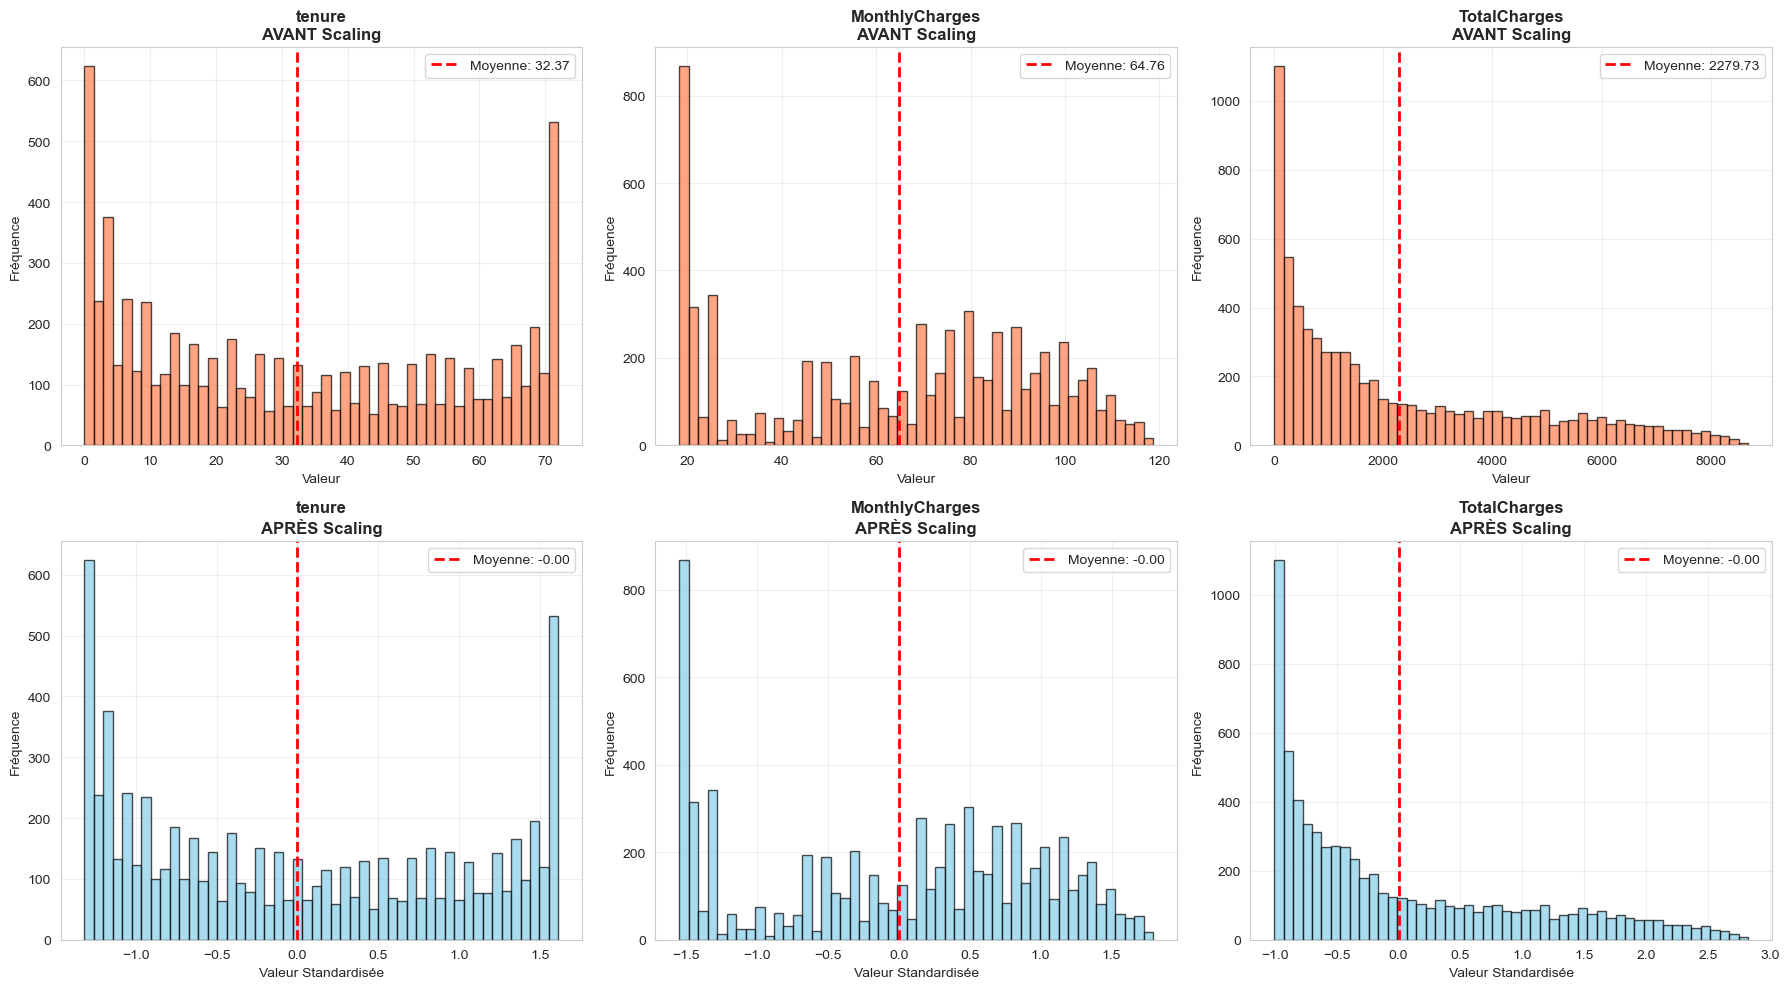

In [36]:
# Visualiser l'effet du scaling
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Récupérer les données originales pour la comparaison
original_data = df_final[cols_to_scale].copy()
scaled_data = df_encoded[cols_to_scale].copy()

for idx, col in enumerate(cols_to_scale):
    # Distribution AVANT scaling
    axes[0, idx].hist(original_data[col].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{col}\nAVANT Scaling', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Valeur')
    axes[0, idx].set_ylabel('Fréquence')
    axes[0, idx].axvline(original_data[col].mean(), color='red', linestyle='--', 
                         linewidth=2, label=f'Moyenne: {original_data[col].mean():.2f}')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Distribution APRÈS scaling
    axes[1, idx].hist(scaled_data[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[1, idx].set_title(f'{col}\nAPRÈS Scaling', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Valeur Standardisée')
    axes[1, idx].set_ylabel('Fréquence')
    axes[1, idx].axvline(scaled_data[col].mean(), color='red', linestyle='--', 
                         linewidth=2, label=f'Moyenne: {scaled_data[col].mean():.2f}')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ANALYSE DE CORRÉLATION - FACTEURS DÉTERMINANTS

📊 TOP 15 FACTEURS POSITIVEMENT CORRÉLÉS AVEC LE CHURN
--------------------------------------------------------------------------------
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService                      0.011942
gender                           -0.008612
MultipleLines_No phone service   -0.011942
DeviceProtection_Yes             -0.066160
OnlineBackup_Yes                 -0.082255
PaymentMethod_Mailed check       -0.091683
Name: Churn, dtype: float64

📊 TOP 15 FACTEURS NÉGATIVEMENT CORRÉLÉS AVEC LE CHURN
--------------------------------------------------------------------------------
Partner 

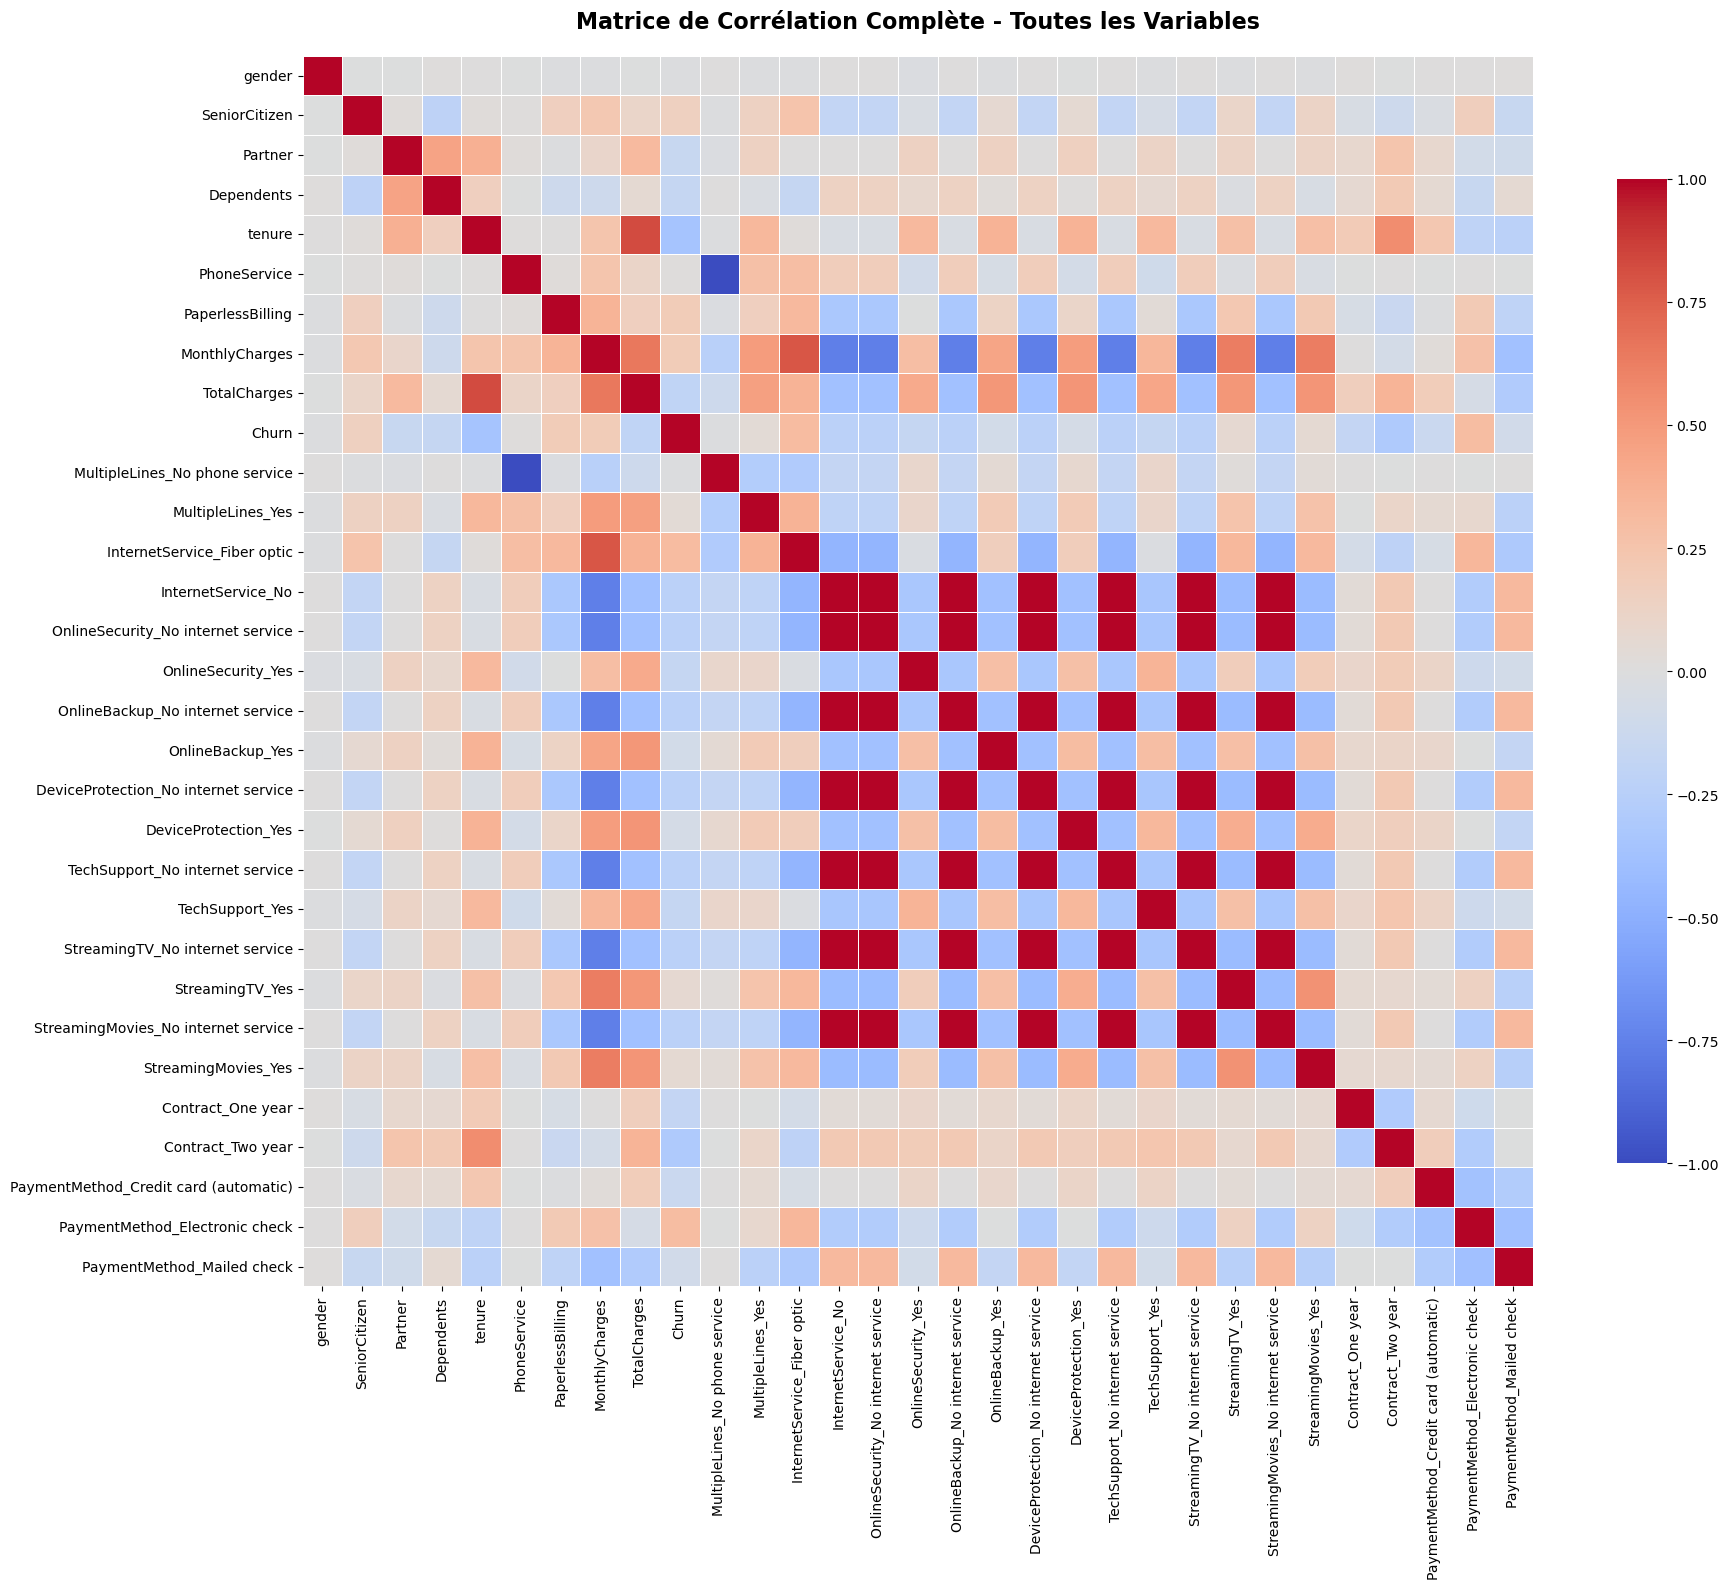

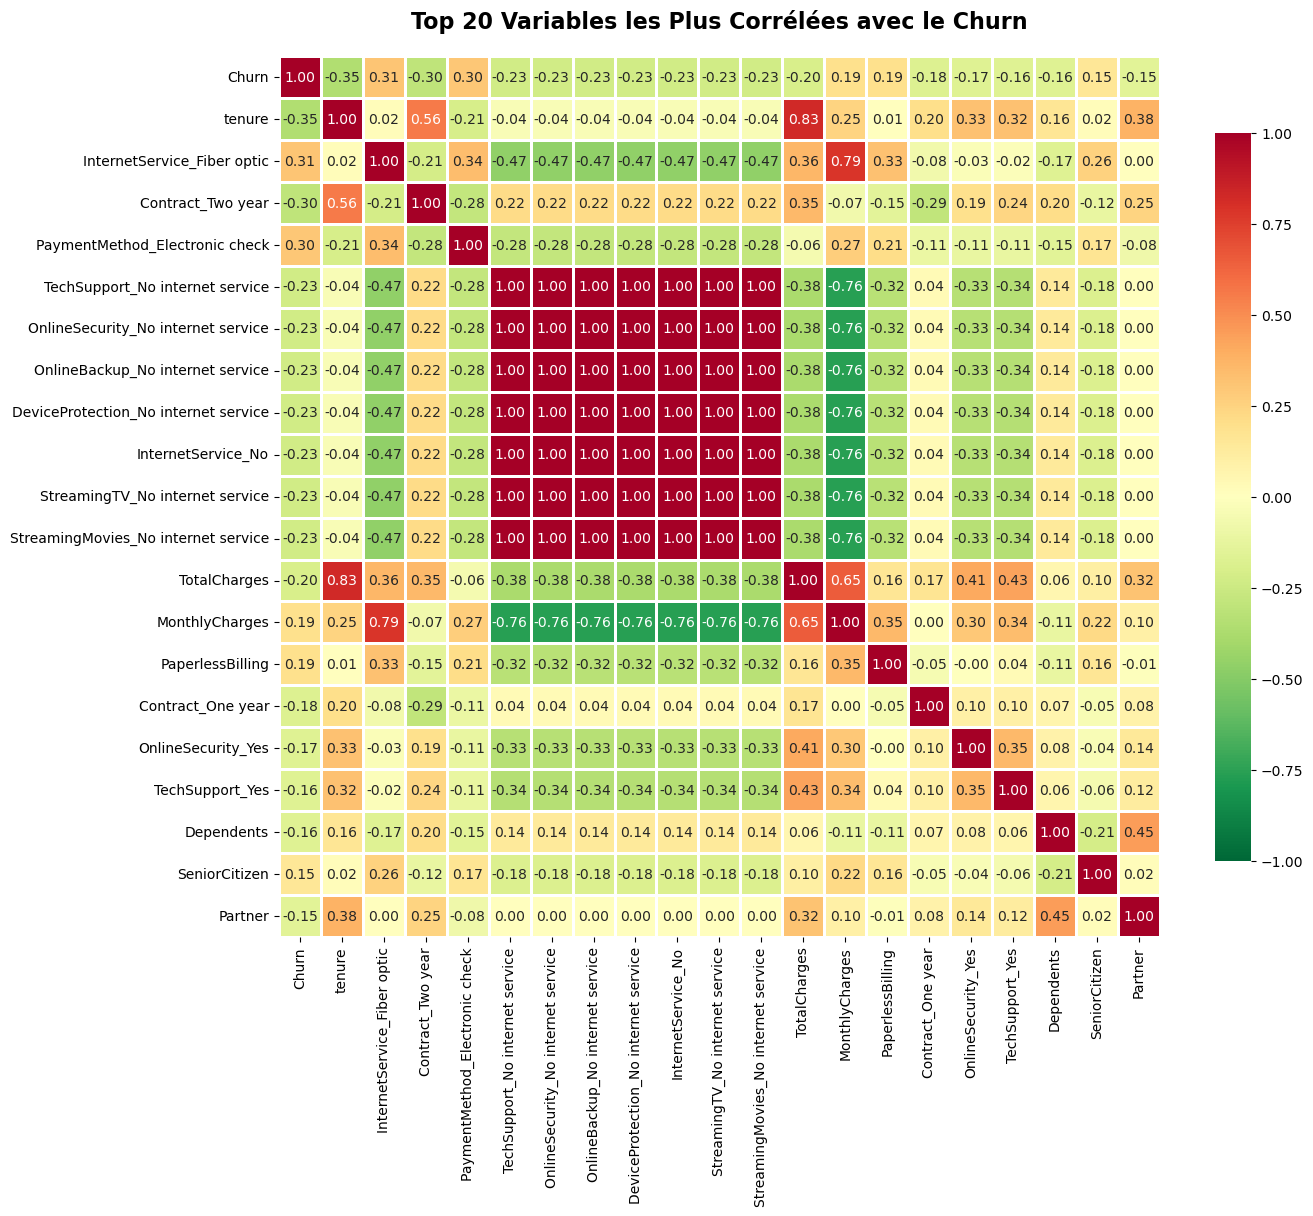

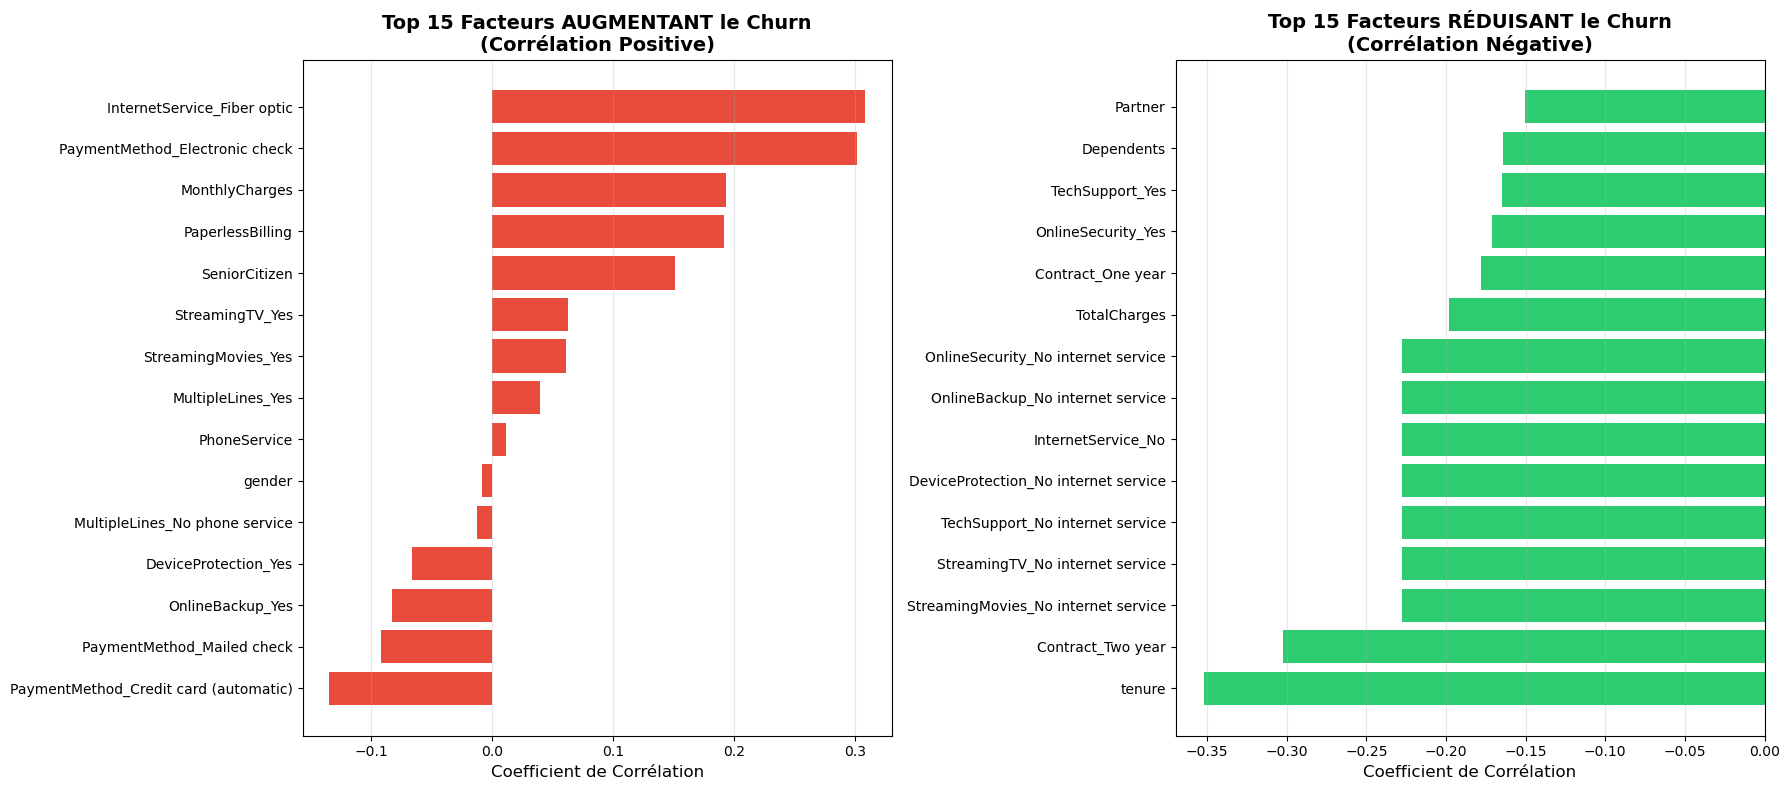


📊 RÉSUMÉ DES INSIGHTS - FACTEURS DÉTERMINANTS DU CHURN

🔴 FACTEURS QUI AUGMENTENT LE CHURN (Corrélation Positive):
--------------------------------------------------------------------------------
 1. InternetService_Fiber optic              : +0.3080
 2. PaymentMethod_Electronic check           : +0.3019
 3. MonthlyCharges                           : +0.1934
 4. PaperlessBilling                         : +0.1918
 5. SeniorCitizen                            : +0.1509
 6. StreamingTV_Yes                          : +0.0632
 7. StreamingMovies_Yes                      : +0.0614
 8. MultipleLines_Yes                        : +0.0401
 9. PhoneService                             : +0.0119
10. gender                                   : -0.0086
11. MultipleLines_No phone service           : -0.0119
12. DeviceProtection_Yes                     : -0.0662
13. OnlineBackup_Yes                         : -0.0823
14. PaymentMethod_Mailed check               : -0.0917
15. PaymentMethod_Credit card (au

In [1]:
# =============================================================================
# ANALYSE DE CORRÉLATION - FACTEURS DÉTERMINANTS DU CHURN
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
DATA_PATH = r"../data/processed/telco_customer_churn_ml_ready.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("ANALYSE DE CORRÉLATION - FACTEURS DÉTERMINANTS")
print("=" * 80)

# Calculer la matrice de corrélation complète
correlation_matrix = df.corr()

# Extraire la corrélation avec la variable cible 'Churn'
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)

print("\n📊 TOP 15 FACTEURS POSITIVEMENT CORRÉLÉS AVEC LE CHURN")
print("-" * 80)
print(churn_correlation.head(15))

print("\n📊 TOP 15 FACTEURS NÉGATIVEMENT CORRÉLÉS AVEC LE CHURN")
print("-" * 80)
print(churn_correlation.tail(15))

# =============================================================================
# VISUALISATION 1 : HEATMAP DE TOUTES LES CORRÉLATIONS
# =============================================================================

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=False,  # Pas d'annotations pour éviter la surcharge
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation Complète - Toutes les Variables', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALISATION 2 : HEATMAP DES CORRÉLATIONS AVEC CHURN
# =============================================================================

# Sélectionner les 20 variables les plus corrélées avec Churn (en valeur absolue)
top_correlations = churn_correlation.abs().sort_values(ascending=False).head(21)  # 21 car Churn est inclus
top_features = top_correlations.index.tolist()

# Créer une sous-matrice
subset_correlation = correlation_matrix.loc[top_features, top_features]

plt.figure(figsize=(14, 12))
sns.heatmap(subset_correlation, 
            annot=True,  # Afficher les valeurs
            fmt='.2f',
            cmap='RdYlGn_r',  # Rouge = forte corrélation positive
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Top 20 Variables les Plus Corrélées avec le Churn', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALISATION 3 : BARPLOT DES CORRÉLATIONS AVEC CHURN
# =============================================================================

# Exclure la corrélation de Churn avec lui-même
churn_corr_no_self = churn_correlation.drop('Churn')

# Top 15 corrélations positives et négatives
top_15_positive = churn_corr_no_self.head(15)
top_15_negative = churn_corr_no_self.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Corrélations positives
axes[0].barh(range(len(top_15_positive)), top_15_positive.values, color='#e74c3c')
axes[0].set_yticks(range(len(top_15_positive)))
axes[0].set_yticklabels(top_15_positive.index, fontsize=10)
axes[0].set_xlabel('Coefficient de Corrélation', fontsize=12)
axes[0].set_title('Top 15 Facteurs AUGMENTANT le Churn\n(Corrélation Positive)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Corrélations négatives
axes[1].barh(range(len(top_15_negative)), top_15_negative.values, color='#2ecc71')
axes[1].set_yticks(range(len(top_15_negative)))
axes[1].set_yticklabels(top_15_negative.index, fontsize=10)
axes[1].set_xlabel('Coefficient de Corrélation', fontsize=12)
axes[1].set_title('Top 15 Facteurs RÉDUISANT le Churn\n(Corrélation Négative)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# =============================================================================
# RÉSUMÉ DES INSIGHTS
# =============================================================================

print("\n" + "=" * 80)
print("📊 RÉSUMÉ DES INSIGHTS - FACTEURS DÉTERMINANTS DU CHURN")
print("=" * 80)

print("\n🔴 FACTEURS QUI AUGMENTENT LE CHURN (Corrélation Positive):")
print("-" * 80)
for i, (feature, corr) in enumerate(top_15_positive.items(), 1):
    print(f"{i:2d}. {feature:40s} : {corr:+.4f}")

print("\n🟢 FACTEURS QUI RÉDUISENT LE CHURN (Corrélation Négative):")
print("-" * 80)
for i, (feature, corr) in enumerate(reversed(list(top_15_negative.items())), 1):
    print(f"{i:2d}. {feature:40s} : {corr:+.4f}")

print("\n" + "=" * 80)
print("✅ Analyse terminée !")
print("=" * 80)

### 9.7 Aperçu du Dataset Final Encodé et Scalé

In [37]:
print("=" * 80)
print("APERÇU DU DATASET FINAL")
print("=" * 80)

print(f"Dimensions: {df_encoded.shape}")
print(f"Types de données:")
print(df_encoded.dtypes.value_counts())

print("\nPremières lignes du dataset encodé:")
display(df_encoded.head())

print("\nInformations sur le dataset:")
df_encoded.info()


APERÇU DU DATASET FINAL
Dimensions: (7043, 32)
Types de données:
int32      27
float64     3
object      1
int64       1
Name: count, dtype: int64

Premières lignes du dataset encodé:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0



Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int32  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int32  
 4   Dependents                             7043 non-null   int32  
 5   tenure                                 7043 non-null   float64
 6   PhoneService                           7043 non-null   int32  
 7   PaperlessBilling                       7043 non-null   int32  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   float64
 10  Churn                                  704

c:\Users\alexi\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\alexi\AppData\Local\Temp\ipykernel_9960\3951007813.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df_month_to_month, x='Churn', y='MonthlyCharges',
c:\Users\alexi\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\alexi\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users

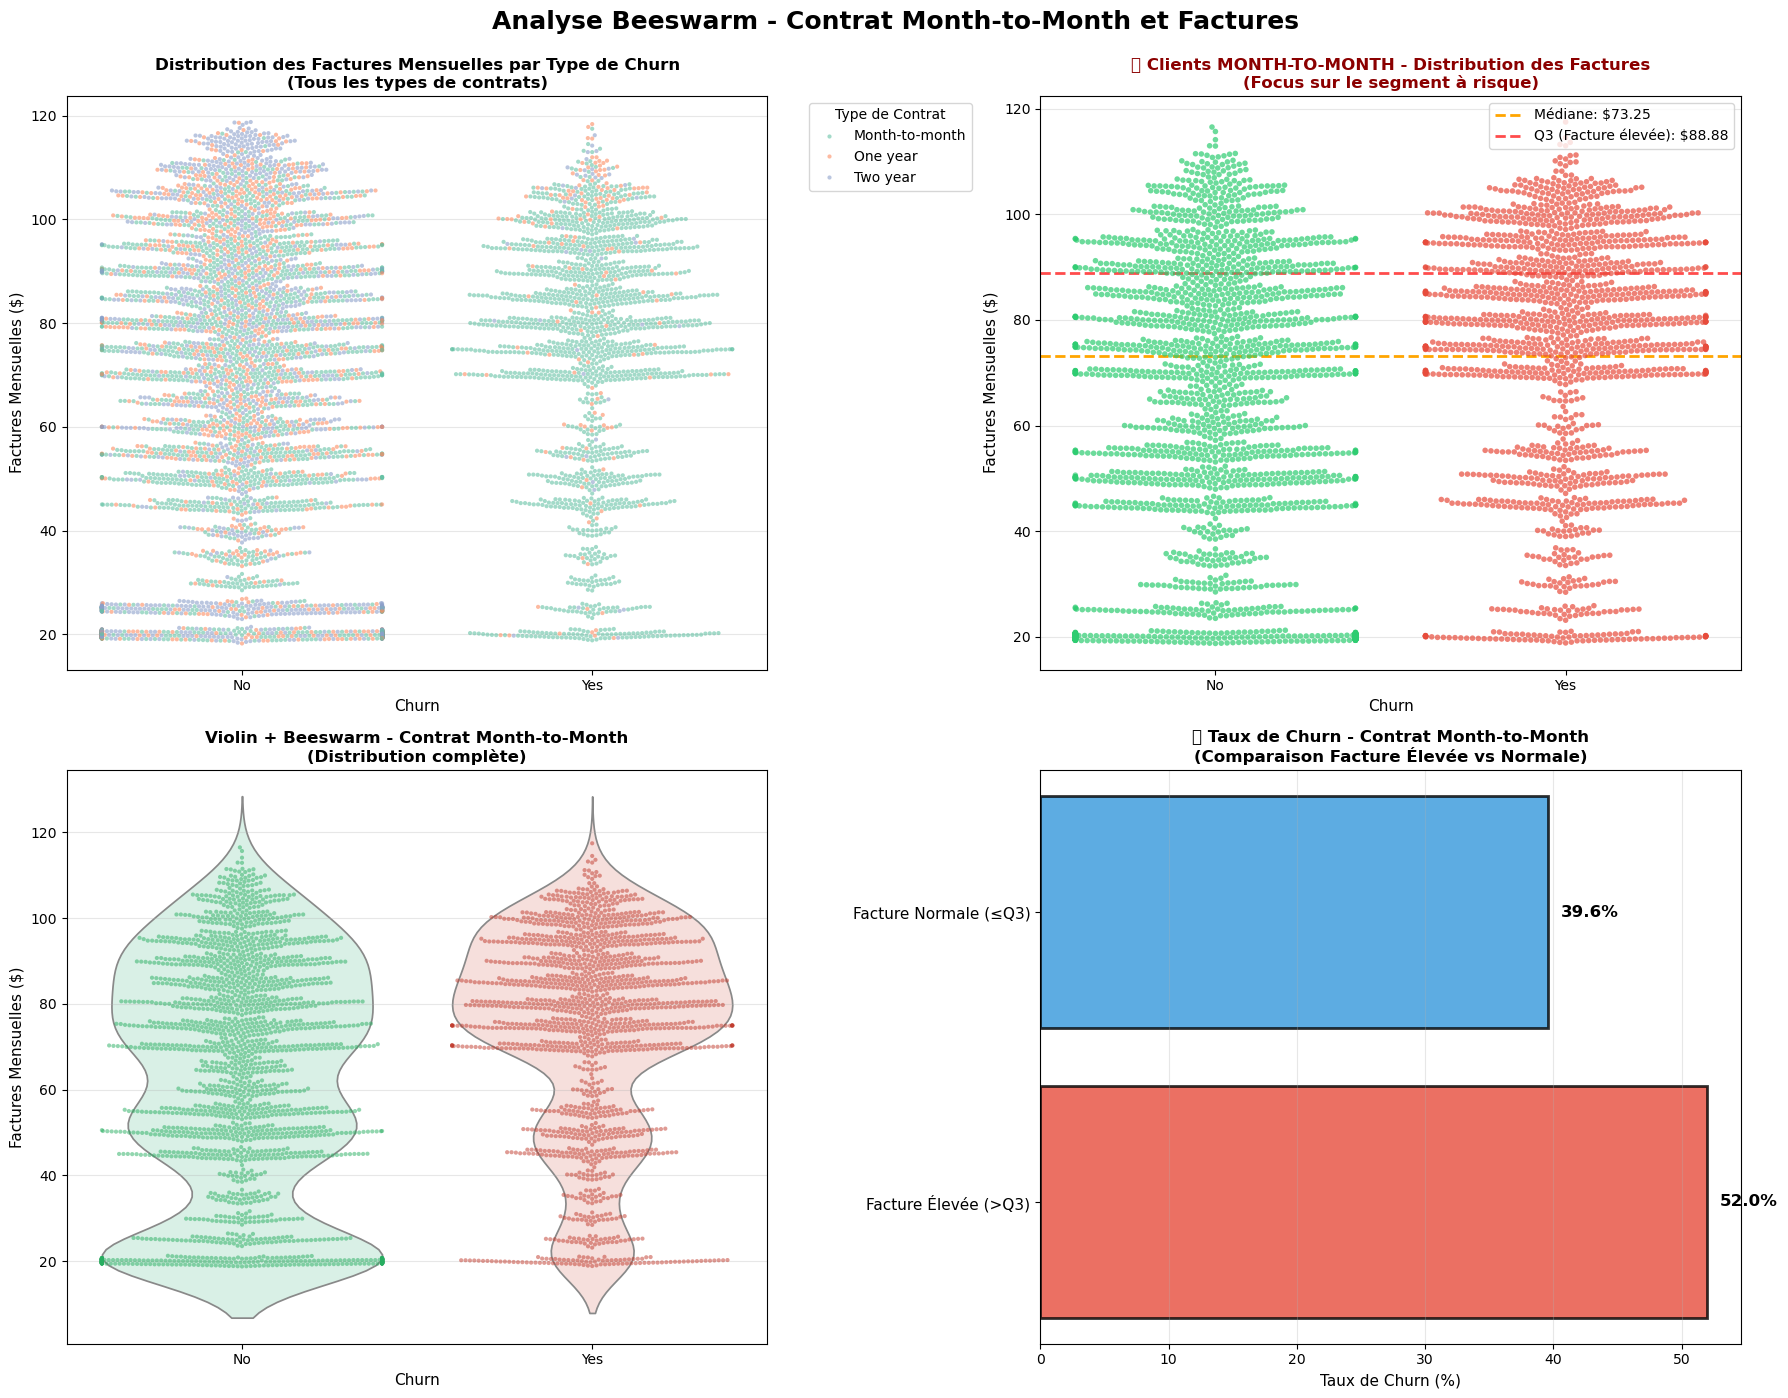

📊 ANALYSE DÉTAILLÉE - CONTRAT MONTH-TO-MONTH ET FACTURES ÉLEVÉES

📌 Nombre total de clients Month-to-Month: 3875
📌 Seuil de 'Facture Élevée' (Q3): $88.88

🔴 TAUX DE CHURN PAR SEGMENT:
--------------------------------------------------------------------------------
Facture Élevée (>Q3)           : 52.01% (504/969 clients)
Facture Normale (≤Q3)          : 39.61% (1151/2906 clients)

📊 STATISTIQUES DES FACTURES - Contrat Month-to-Month:
--------------------------------------------------------------------------------
        count       mean        std    min      25%    50%      75%     max
Churn                                                                      
No     2220.0  61.462635  27.863547  18.75  38.5375  64.95  84.9125  116.50
Yes    1655.0  73.019396  24.084146  18.85  55.2000  79.05  90.8750  117.45

✅ Analyse terminée !


In [3]:
# =============================================================================
# ANALYSE BEESWARM - Contrat Month-to-Month et Factures Élevées
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données AVANT preprocessing (pour avoir les variables catégorielles)
DATA_PATH_RAW = r"../data/processed/telco_customer_churn_clean.csv"  # Données avant encoding
df_raw = pd.read_csv(DATA_PATH_RAW)

# Créer une figure avec plusieurs visualisations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Analyse Beeswarm - Contrat Month-to-Month et Factures', 
             fontsize=18, fontweight='bold', y=0.995)

# ============================================================================
# GRAPHIQUE 1 : Beeswarm - MonthlyCharges par Churn (tous contrats)
# ============================================================================
ax1 = axes[0, 0]
sns.swarmplot(data=df_raw, x='Churn', y='MonthlyCharges', 
              hue='Contract', palette='Set2', 
              size=3, alpha=0.6, ax=ax1)
ax1.set_title('Distribution des Factures Mensuelles par Type de Churn\n(Tous les types de contrats)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Churn', fontsize=11)
ax1.set_ylabel('Factures Mensuelles ($)', fontsize=11)
ax1.legend(title='Type de Contrat', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# ============================================================================
# GRAPHIQUE 2 : Beeswarm - Month-to-Month uniquement
# ============================================================================
ax2 = axes[0, 1]
df_month_to_month = df_raw[df_raw['Contract'] == 'Month-to-month']
sns.swarmplot(data=df_month_to_month, x='Churn', y='MonthlyCharges',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              size=4, alpha=0.7, ax=ax2)
ax2.set_title('🔴 Clients MONTH-TO-MONTH - Distribution des Factures\n(Focus sur le segment à risque)', 
              fontsize=12, fontweight='bold', color='darkred')
ax2.set_xlabel('Churn', fontsize=11)
ax2.set_ylabel('Factures Mensuelles ($)', fontsize=11)
ax2.axhline(y=df_month_to_month['MonthlyCharges'].median(), 
            color='orange', linestyle='--', linewidth=2, 
            label=f'Médiane: ${df_month_to_month["MonthlyCharges"].median():.2f}')
ax2.axhline(y=df_month_to_month['MonthlyCharges'].quantile(0.75), 
            color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Q3 (Facture élevée): ${df_month_to_month["MonthlyCharges"].quantile(0.75):.2f}')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

# ============================================================================
# GRAPHIQUE 3 : Violin Plot avec Beeswarm superposé
# ============================================================================
ax3 = axes[1, 0]
sns.violinplot(data=df_month_to_month, x='Churn', y='MonthlyCharges',
               palette={'No': '#d5f4e6', 'Yes': '#fadbd8'},
               inner=None, ax=ax3)
sns.swarmplot(data=df_month_to_month, x='Churn', y='MonthlyCharges',
              palette={'No': '#27ae60', 'Yes': '#c0392b'},
              size=3, alpha=0.5, ax=ax3)
ax3.set_title('Violin + Beeswarm - Contrat Month-to-Month\n(Distribution complète)', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Churn', fontsize=11)
ax3.set_ylabel('Factures Mensuelles ($)', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# ============================================================================
# GRAPHIQUE 4 : Statistiques - Factures élevées et Churn
# ============================================================================
ax4 = axes[1, 1]

# Définir "facture élevée" comme Q3 (75e percentile)
high_charge_threshold = df_month_to_month['MonthlyCharges'].quantile(0.75)

# Créer des segments
df_month_to_month['Segment'] = df_month_to_month['MonthlyCharges'].apply(
    lambda x: 'Facture Élevée (>Q3)' if x > high_charge_threshold else 'Facture Normale (≤Q3)'
)

# Calculer le taux de churn par segment
churn_by_segment = df_month_to_month.groupby('Segment')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

# Barplot
bars = ax4.barh(range(len(churn_by_segment)), churn_by_segment.values, 
                color=['#e74c3c', '#3498db'], alpha=0.8, edgecolor='black', linewidth=2)
ax4.set_yticks(range(len(churn_by_segment)))
ax4.set_yticklabels(churn_by_segment.index, fontsize=11)
ax4.set_xlabel('Taux de Churn (%)', fontsize=11)
ax4.set_title('📊 Taux de Churn - Contrat Month-to-Month\n(Comparaison Facture Élevée vs Normale)', 
              fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, churn_by_segment.values)):
    width = bar.get_width()
    ax4.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%',
             ha='left', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# STATISTIQUES DÉTAILLÉES
# =============================================================================

print("=" * 80)
print("📊 ANALYSE DÉTAILLÉE - CONTRAT MONTH-TO-MONTH ET FACTURES ÉLEVÉES")
print("=" * 80)

print(f"\n📌 Nombre total de clients Month-to-Month: {len(df_month_to_month)}")
print(f"📌 Seuil de 'Facture Élevée' (Q3): ${high_charge_threshold:.2f}")

print("\n🔴 TAUX DE CHURN PAR SEGMENT:")
print("-" * 80)
for segment, rate in churn_by_segment.items():
    count = len(df_month_to_month[df_month_to_month['Segment'] == segment])
    churn_count = (df_month_to_month[df_month_to_month['Segment'] == segment]['Churn'] == 'Yes').sum()
    print(f"{segment:30s} : {rate:5.2f}% ({churn_count}/{count} clients)")

# Statistiques par segment et churn
print("\n📊 STATISTIQUES DES FACTURES - Contrat Month-to-Month:")
print("-" * 80)
stats = df_month_to_month.groupby('Churn')['MonthlyCharges'].describe()
print(stats)

print("\n" + "=" * 80)
print("✅ Analyse terminée !")
print("=" * 80)

### 9.8 Sauvegarde du Dataset Préparé pour le ML

In [38]:
# Supprimer la colonne customerID qui n'est pas utile pour le modèle
df_ml_ready = df_encoded.drop(columns=['customerID'])

# Sauvegarder le dataset prêt pour le ML
ML_OUTPUT_PATH = Path(r"../data/processed/telco_customer_churn_ml_ready.csv")
df_ml_ready.to_csv(ML_OUTPUT_PATH, index=False)

print("=" * 80)
print("✓ DATASET PRÊT POUR LE MACHINE LEARNING")
print("=" * 80)
print(f"\n✓ Fichier sauvegardé: {ML_OUTPUT_PATH}")
print(f"✓ Dimensions: {df_ml_ready.shape[0]} lignes × {df_ml_ready.shape[1]} colonnes")
print(f"✓ Variables numériques scalées: {cols_to_scale}")
print(f"✓ Variables binaires encodées: {len(binary_cols)} colonnes")
print(f"✓ Variables one-hot encodées: {len(multi_categorical_cols)} catégories originales")
print(f"\n✓ Le dataset est maintenant prêt pour l'entraînement de modèles ML !")


✓ DATASET PRÊT POUR LE MACHINE LEARNING

✓ Fichier sauvegardé: ..\data\processed\telco_customer_churn_ml_ready.csv
✓ Dimensions: 7043 lignes × 31 colonnes
✓ Variables numériques scalées: ['tenure', 'MonthlyCharges', 'TotalCharges']
✓ Variables binaires encodées: 5 colonnes
✓ Variables one-hot encodées: 10 catégories originales

✓ Le dataset est maintenant prêt pour l'entraînement de modèles ML !


## Résumé Complet du Preprocessing
### Actions Effectuées:
 1. ✓ Chargement du dataset original
 2. ✓ Identification des espaces vides dans `TotalCharges`
 3. ✓ Conversion des espaces vides en valeurs `NaN`
 4. ✓ Comparaison de 4 stratégies de gestion des valeurs manquantes
 5. ✓ Application de la stratégie recommandée (MonthlyCharges × tenure)
 6. ✓ Sauvegarde du dataset nettoyé
 7. ✓ Encodage des variables catégorielles (LabelEncoder + OneHotEncoder)
 8. ✓ Scaling des variables numériques (StandardScaler)
 9. ✓ Sauvegarde du dataset prêt pour le ML

 ### Résultats:
 - **Dataset nettoyé**: `telco_customer_churn_clean.csv`
 - **Dataset ML-ready**: `telco_customer_churn_ml_ready.csv`
 - **Toutes les données préservées**: Aucune ligne supprimée
 - **Valeurs manquantes**: 0
 - **Variables encodées**: Binaires (LabelEncoder) + Multi-catégorielles (OneHot)
 - **Variables scalées**: tenure, MonthlyCharges, TotalCharges (moyenne=0, std=1)
 - **Prêt pour le ML**: Oui ✓
